# <center> 2. Descriptive Analysis

In [114]:
# importing required libraries
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

#### 1. Importing the cleaned data from the file into a dataframe.

In [5]:
dfT1DData = pd.read_excel("../SourceData/Processed/Team10_PythonWranglers_CleanedData.xlsx")

## 1. What is the demographic breakdown of patients?

### *Reasoning: Understanding the breakdown of patients especially with respect to age and gender can gibe us a better understanding of the data and help us analysis.*

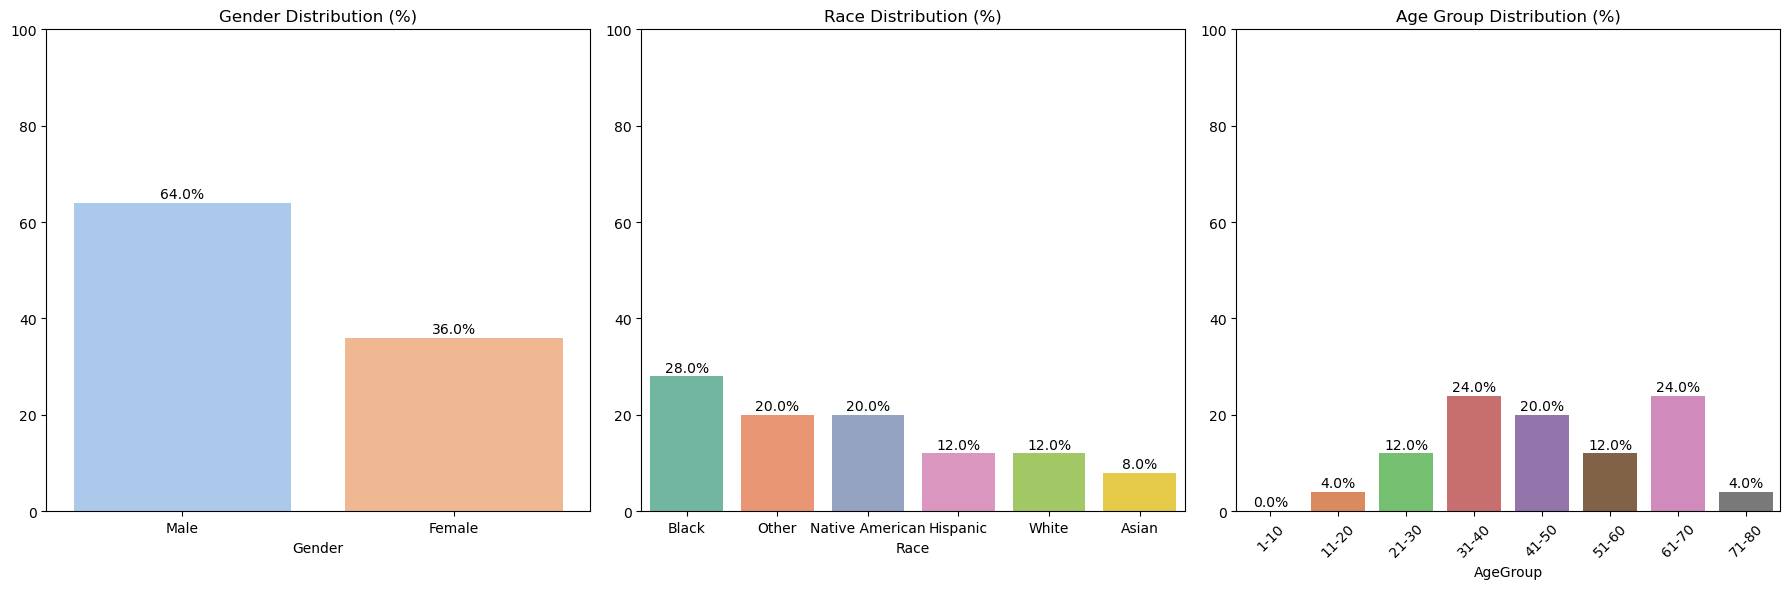

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Collapse to unique patients and rename to dfDemographicsData ---
dfDemographicsData = dfT1DData[['patient_id', 'Age', 'Gender', 'Race']].drop_duplicates()

# --- Create 10-year age groups starting at 1 ---
bins = range(1, dfDemographicsData['Age'].max() + 10, 10)
labels = [f"{i}-{i+9}" for i in bins[:-1]]
dfDemographicsData['AgeGroup'] = pd.cut(dfDemographicsData['Age'], bins=bins, labels=labels, right=True)

# --- Calculate percentages ---
gender_counts = dfDemographicsData['Gender'].value_counts(normalize=True) * 100
race_counts = dfDemographicsData['Race'].value_counts(normalize=True) * 100
age_counts = dfDemographicsData['AgeGroup'].value_counts(normalize=True).sort_index() * 100

# --- Plot side-by-side ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gender
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0], palette="pastel")
axes[0].set_title("Gender Distribution (%)")
axes[0].set_ylim(0, 100)  # standardize to percentage scale
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center')

# Race
sns.barplot(x=race_counts.index, y=race_counts.values, ax=axes[1], palette="Set2")
axes[1].set_title("Race Distribution (%)")
axes[1].set_ylim(0, 100)
for i, v in enumerate(race_counts.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center')

# Age groups
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[2], palette="muted")
axes[2].set_title("Age Group Distribution (%)")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(age_counts.values):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

## 2. What is the average blood glucose level of all patients, and how much time do they spend within target range (70 - 180 mg/dL), below 70 (hypoglycemia) and above 180 (hyperglycemia)?

### *Reasoning: Understanding the average blood glucose values of each patient as well as the amount of time they are spending in range will help guide our analysis.*


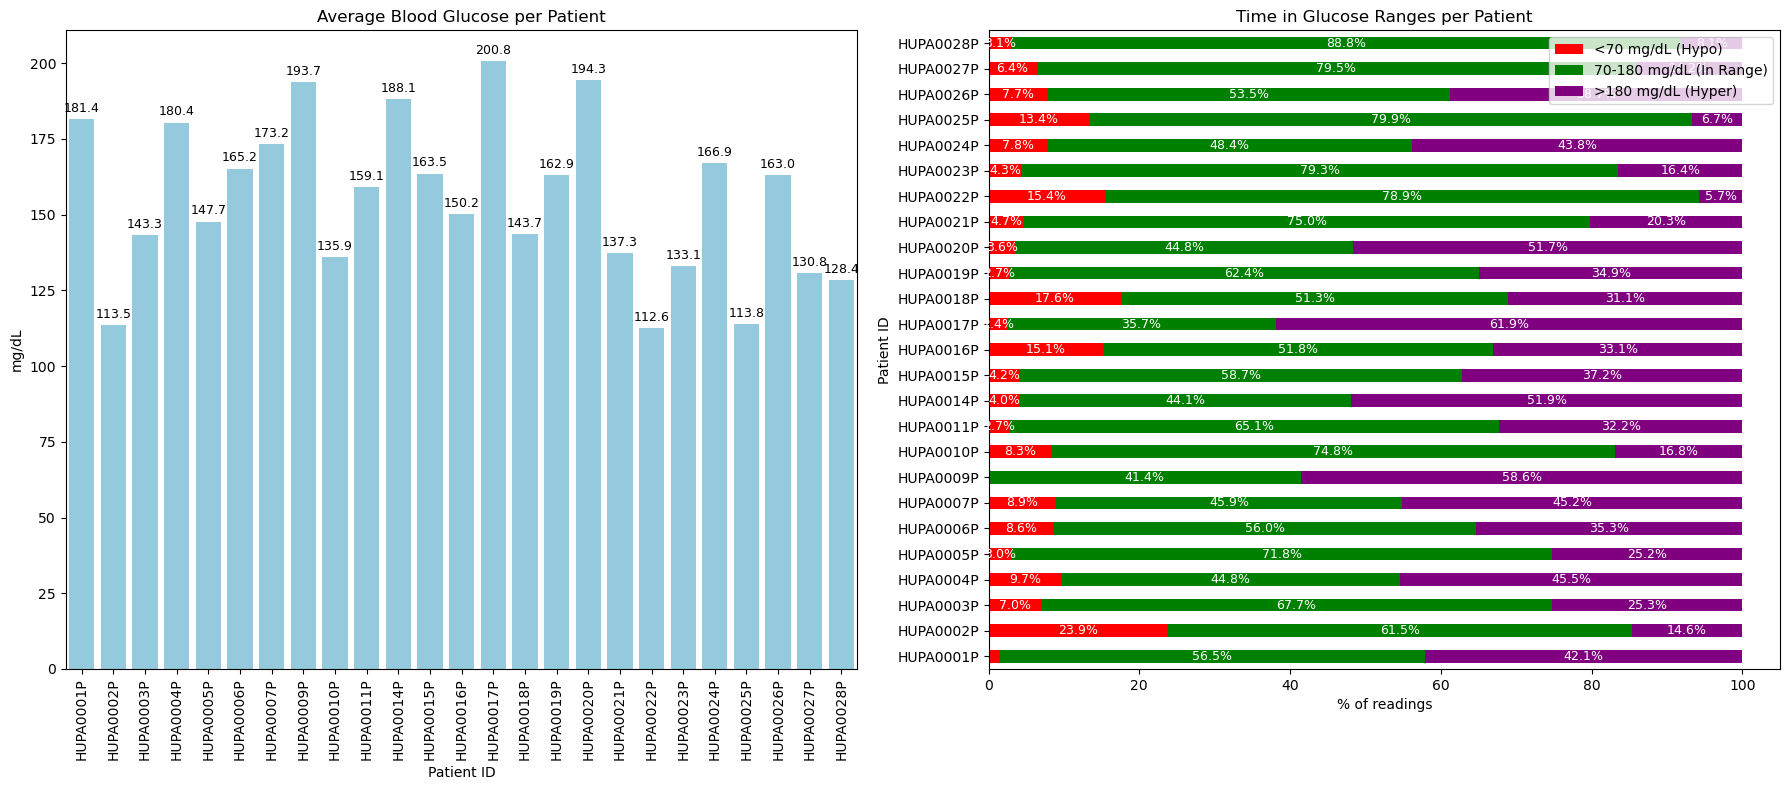

In [120]:
# --- Step 1: Calculate metrics per patient ---
results = []

for pid, group in dfT1DData.groupby('patient_id'):
    avg_glucose = group['glucose'].mean()
    total = len(group)
    
    time_in_range = (group['glucose'].between(70, 180)).sum() / total * 100
    time_below = (group['glucose'] < 70).sum() / total * 100
    time_above = (group['glucose'] > 180).sum() / total * 100
    
    results.append({
        'patient_id': pid,
        'avg_glucose': avg_glucose,
        'time_below_%': time_below,
        'time_in_range_%': time_in_range,
        'time_above_%': time_above
    })

df_metrics = pd.DataFrame(results)

# --- Step 2: Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left Chart: Average Glucose per Patient ---
sns.barplot(x='patient_id', y='avg_glucose', data=df_metrics,
            ax=axes[0], color='skyblue')

# Add labels on bars
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.1f'),  
                     (p.get_x() + p.get_width() / 2., p.get_height()),  
                     ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                     textcoords='offset points')

axes[0].set_title("Average Blood Glucose per Patient")
axes[0].set_ylabel("mg/dL")
axes[0].set_xlabel("Patient ID")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90)

# --- Right Chart: Stacked Horizontal Bar for Time in Ranges ---
stacked_data = df_metrics.set_index('patient_id')[['time_below_%', 'time_in_range_%', 'time_above_%']]

colors = ['red', 'green', 'purple']
stacked_data.plot(kind='barh', stacked=True, ax=axes[1], color=colors)

# Add labels on each segment
for i, patient in enumerate(stacked_data.index):
    left = 0
    for j, col in enumerate(stacked_data.columns):
        width = stacked_data.loc[patient, col]
        if width > 2:  # only label if segment is wide enough
            axes[1].text(left + width/2, i, f'{width:.1f}%', ha='center', va='center', color='white', fontsize=9)
        left += width

axes[1].set_xlabel("% of readings")
axes[1].set_ylabel("Patient ID")
axes[1].set_title("Time in Glucose Ranges per Patient")
axes[1].legend(['<70 mg/dL (Hypo)', '70-180 mg/dL (In Range)', '>180 mg/dL (Hyper)'], loc='upper right')

plt.tight_layout()
plt.show()

## 3. What is the distribution of glucose readings (minimum, maximum, median, mean, standard deviation) showing how stable or variable their sugars are?

### *Reasoning: Understanding the glucose profiles of participants is essential to the analysis.*

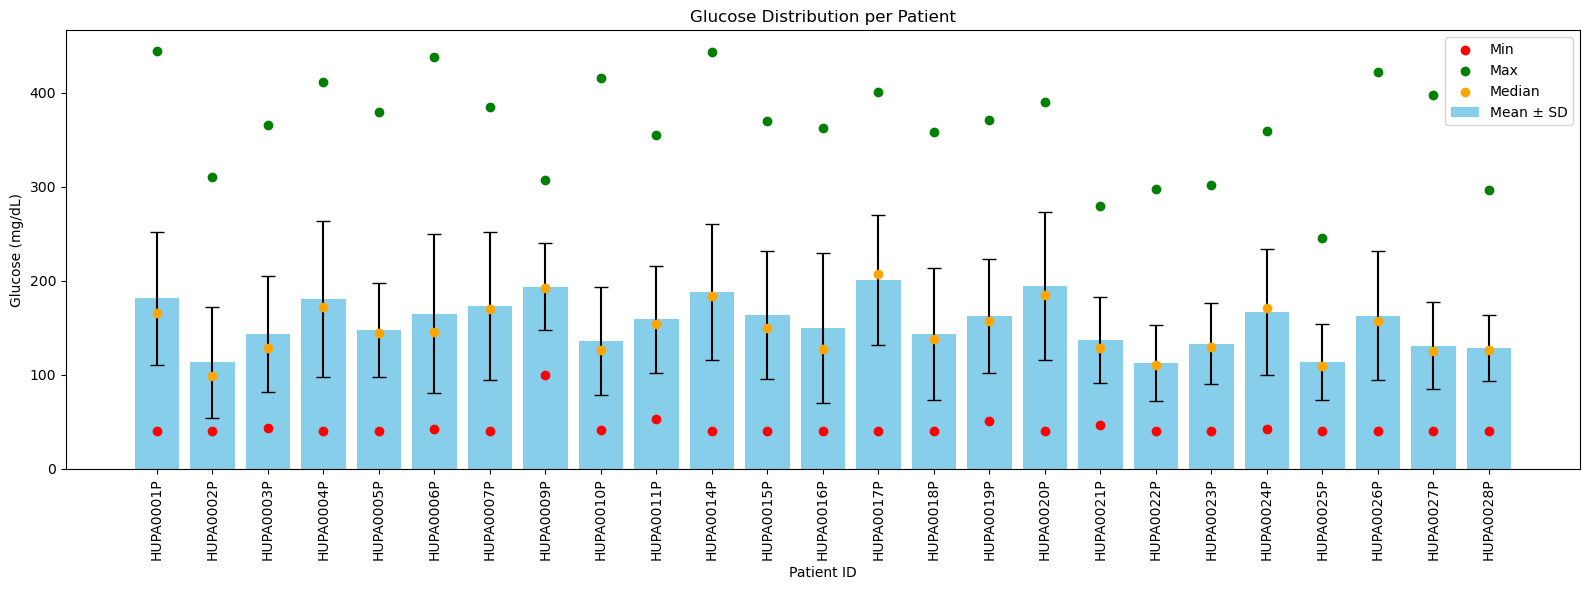

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Calculate summary statistics per patient ---
summary_stats = dfT1DData.groupby('patient_id')['glucose'].agg(['min', 'max', 'mean', 'median', 'std']).reset_index()

# --- Step 2: Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

# Bar for mean glucose
ax.bar(summary_stats['patient_id'], summary_stats['mean'], yerr=summary_stats['std'], capsize=5, color='skyblue', label='Mean ± SD')

# Overlay min, max, median as points
ax.scatter(summary_stats['patient_id'], summary_stats['min'], color='red', label='Min', zorder=5)
ax.scatter(summary_stats['patient_id'], summary_stats['max'], color='green', label='Max', zorder=5)
ax.scatter(summary_stats['patient_id'], summary_stats['median'], color='orange', label='Median', zorder=5)

# Decorations
ax.set_xlabel("Patient ID")
ax.set_ylabel("Glucose (mg/dL)")
ax.set_title("Glucose Distribution per Patient")
ax.set_xticklabels(summary_stats['patient_id'], rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

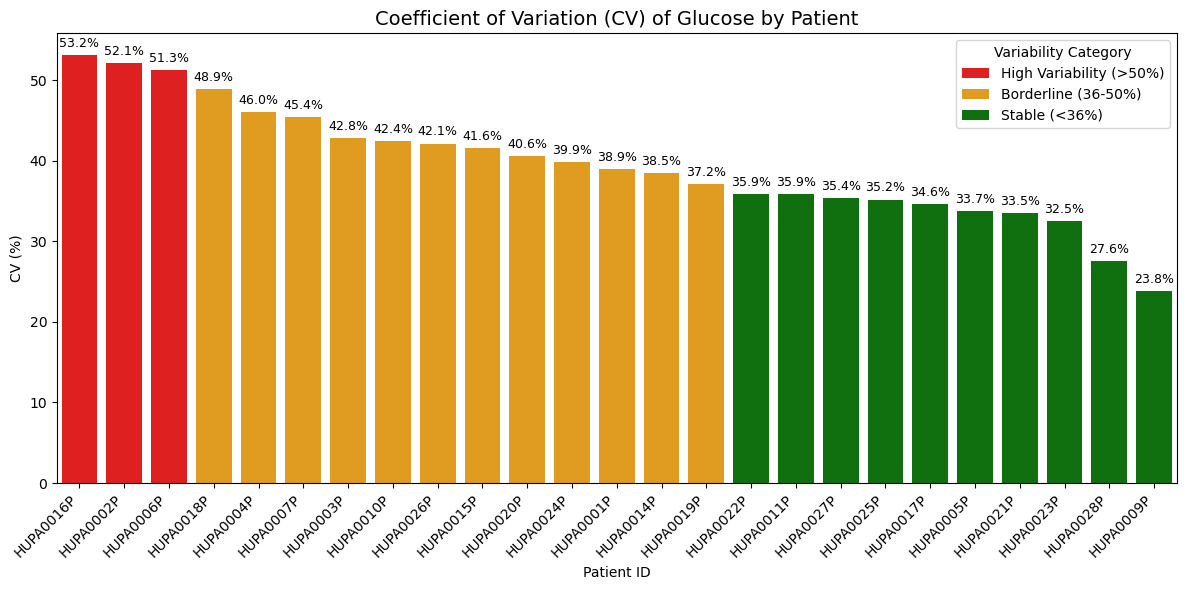

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Calculate Mean, SD, and CV per patient ---
df_variability = dfT1DData.groupby("patient_id")['glucose'].agg(['mean', 'std']).reset_index()
df_variability['CV'] = (df_variability['std'] / df_variability['mean']) * 100

# --- Step 2: Define categories for CV ---
def cv_category(cv):
    if cv < 36:
        return "Stable (<36%)"
    elif cv < 50:
        return "Borderline (36-50%)"
    else:
        return "High Variability (>50%)"

df_variability['CV_Category'] = df_variability['CV'].apply(cv_category)

# --- Step 3: Sort by CV ---
df_variability = df_variability.sort_values(by='CV', ascending=False)

# --- Step 4: Plot ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_variability,
    x='patient_id',
    y='CV',
    hue='CV_Category',
    dodge=False,
    palette={'Stable (<36%)': 'green', 
             'Borderline (36-50%)': 'orange', 
             'High Variability (>50%)': 'red'}
)

# Add labels on bars
for i, v in enumerate(df_variability['CV']):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=9)

plt.title("Coefficient of Variation (CV) of Glucose by Patient", fontsize=14)
plt.xlabel("Patient ID")
plt.ylabel("CV (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Variability Category")
plt.tight_layout()
plt.show()

## 5.	What is the average bolus insulin delivered per day, emphasizing bolus insulin volume variability?
### Bolus insulin volume variability measures how consistently someone doses their mealtime insulin. A variability above 80% signifies extreme inconsistency, often caused by erratic eating patterns or reactive (rather than planned) dosing. This high variability dramatically increases the risk of both dangerous high and low blood glucose events.

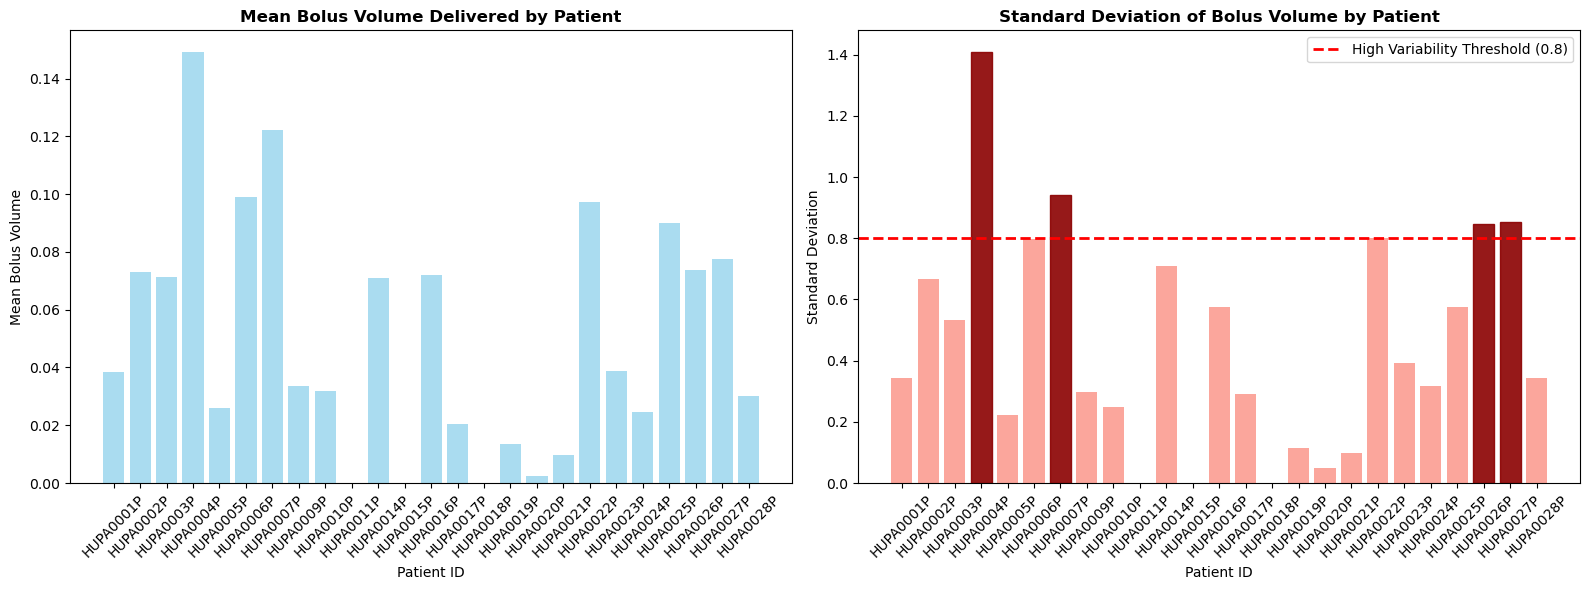

In [125]:

# Calculate mean and standard deviation
mean_bolus = dfT1DData.groupby('patient_id')['bolus_volume_delivered'].mean()
std_bolus = dfT1DData.groupby('patient_id')['bolus_volume_delivered'].std()

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left chart: Mean Bolus Volume
ax1.bar(mean_bolus.index.astype(str), mean_bolus.values, color='skyblue', alpha=0.7)
ax1.set_title('Mean Bolus Volume Delivered by Patient', fontweight='bold')
ax1.set_xlabel('Patient ID')
ax1.set_ylabel('Mean Bolus Volume')
ax1.tick_params(axis='x', rotation=45)

# Right chart: Standard Deviation of Bolus Volume
bars = ax2.bar(std_bolus.index.astype(str), std_bolus.values, color='salmon', alpha=0.7)
ax2.set_title('Standard Deviation of Bolus Volume by Patient', fontweight='bold')
ax2.set_xlabel('Patient ID')
ax2.set_ylabel('Standard Deviation')
ax2.tick_params(axis='x', rotation=45)

# Add extreme variability line at 0.8
ax2.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='High Variability Threshold (0.8)')
ax2.legend()

# Highlight bars above the threshold
for i, bar in enumerate(bars):
    if std_bolus.values[i] > 0.8:
        bar.set_color('darkred')
        bar.set_alpha(0.9)

plt.tight_layout()
plt.show()

## 6.	What is the average daily carbohydrate intake per patient, and how does it compare across participants?

### This analysis provides a crucial baseline for understanding patient-specific carbohydrate patterns, which is essential for accurate bolus insulin dosing and predictive blood glucose forecasting.

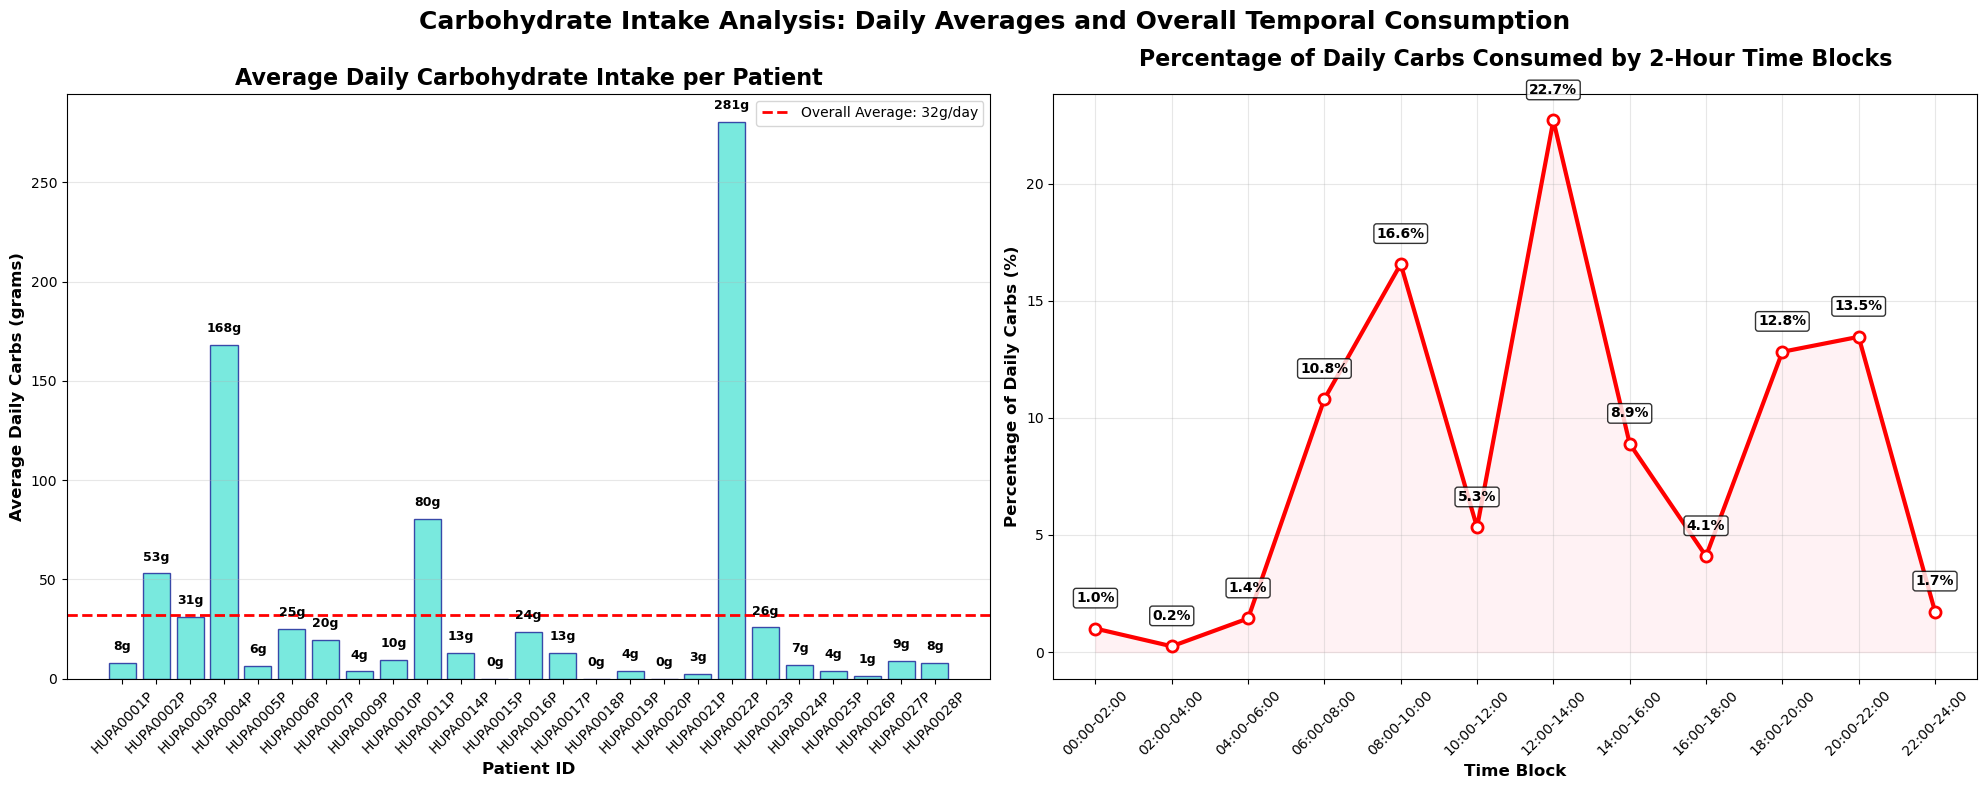

In [127]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# First plot: Average Daily Carbohydrate Intake per Patient
avg_daily_carbs = dfT1DData.groupby(['patient_id', 'date'])['carb_input'].sum().groupby('patient_id').mean()
bars = ax1.bar(avg_daily_carbs.index.astype(str), avg_daily_carbs.values, 
               color='turquoise', alpha=0.7, edgecolor='darkblue')

ax1.set_title('Average Daily Carbohydrate Intake per Patient', fontsize=16, fontweight='bold')
ax1.set_xlabel('Patient ID', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Daily Carbs (grams)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height:.0f}g', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add overall average line
overall_avg = avg_daily_carbs.mean()
ax1.axhline(y=overall_avg, color='red', linestyle='--', linewidth=2,
            label=f'Overall Average: {overall_avg:.0f}g/day')

ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Second plot: Percentage of Daily Carbs by Time Block
dfT1DData['hour'] = pd.to_datetime(dfT1DData['time']).dt.hour
dfT1DData['time_block'] = pd.cut(dfT1DData['hour'], 
                                bins=[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24],
                                labels=['00:00-02:00', '02:00-04:00', '04:00-06:00',
                                        '06:00-08:00', '08:00-10:00', '10:00-12:00',
                                        '12:00-14:00', '14:00-16:00', '16:00-18:00',
                                        '18:00-20:00', '20:00-22:00', '22:00-24:00'])

daily_carbs = dfT1DData.groupby(['patient_id', 'date'])['carb_input'].sum()
timeblock_carbs = dfT1DData.groupby(['patient_id', 'date', 'time_block'])['carb_input'].sum()
percent_by_timeblock = (timeblock_carbs / daily_carbs * 100).reset_index()

timeblock_avg = percent_by_timeblock.groupby('time_block')['carb_input'].mean()

# Create line chart with markers
ax2.plot(timeblock_avg.index, timeblock_avg.values, 
         marker='o', markersize=8, linewidth=3, color='red', 
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='red')

# Fill under the line for better visualization
ax2.fill_between(timeblock_avg.index, timeblock_avg.values, alpha=0.2, color='pink')

ax2.set_title('Percentage of Daily Carbs Consumed by 2-Hour Time Blocks', 
              fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Time Block', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage of Daily Carbs (%)', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# Add value labels on points
for i, (time_block, percentage) in enumerate(timeblock_avg.items()):
    ax2.text(i, percentage + 1, f'{percentage:.1f}%', 
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

ax2.grid(alpha=0.3)

# Add overall title
plt.suptitle('Carbohydrate Intake Analysis: Daily Averages and Overall Temporal Consumption', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

## 7.	What is the average daily step count and calorie expenditure, reflecting patients’ overall activity levels?

### This analysis quantifies patients' daily physical activity patterns, establishing a baseline for understanding how exercise influences glycemic control and insulin requirements.

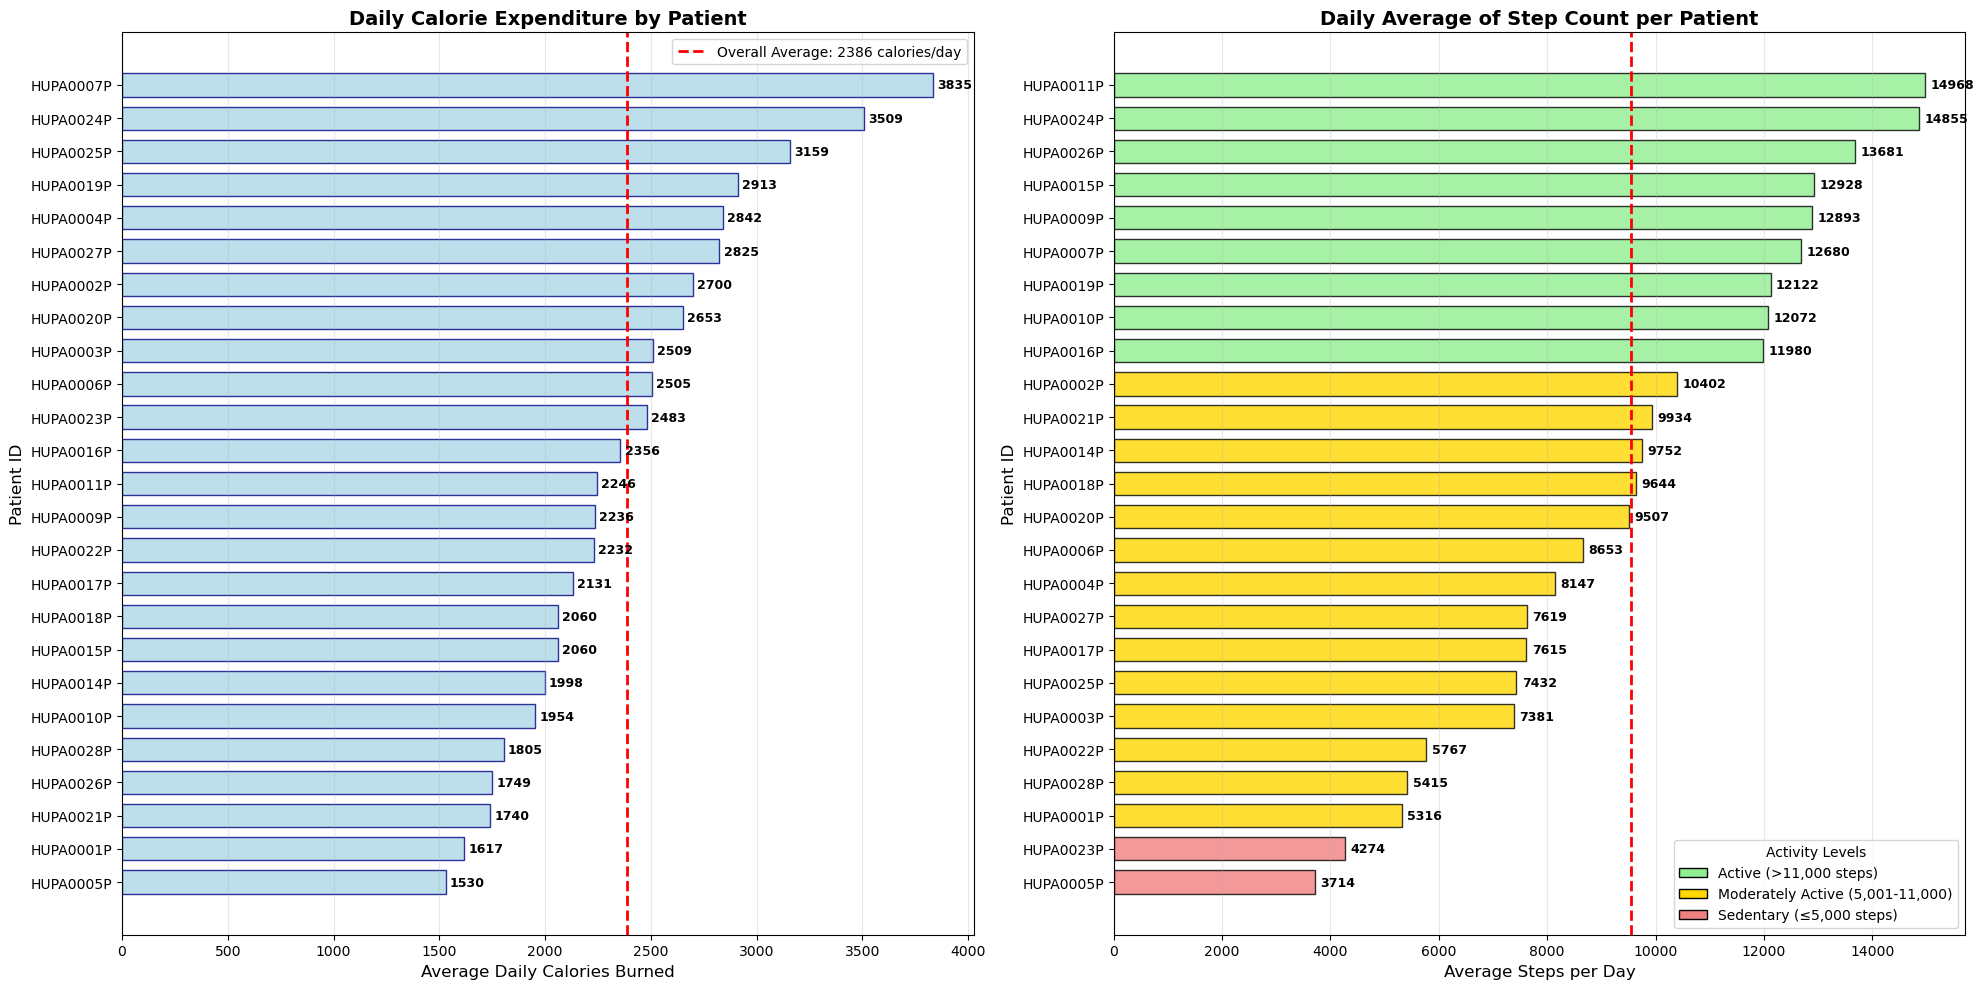

In [129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# --- LEFT: Daily Average Calories by Patient (HORIZONTAL) ---
daily_calories = dfT1DData.groupby(['patient_id', 'date'])['calories'].sum()
avg_daily_calories = daily_calories.groupby('patient_id').mean()
avg_daily_sorted_cal = avg_daily_calories.sort_values(ascending=True)

bars_cal = ax1.barh(avg_daily_sorted_cal.index.astype(str), avg_daily_sorted_cal.values, 
                   color='lightblue', alpha=0.8, edgecolor='navy', height=0.7)
ax1.set_title('Daily Calorie Expenditure by Patient', fontsize=14, fontweight='bold')
ax1.set_xlabel('Average Daily Calories Burned', fontsize=12)
ax1.set_ylabel('Patient ID', fontsize=12)
ax1.grid(axis='x', alpha=0.3)

for bar in bars_cal:
    width = bar.get_width()
    ax1.text(width + 20, bar.get_y() + bar.get_height()/2, f'{width:.0f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')

overall_avg_cal = avg_daily_sorted_cal.mean()
ax1.axvline(x=overall_avg_cal, color='red', linestyle='--', linewidth=2,
            label=f'Overall Average: {overall_avg_cal:.0f} calories/day')
ax1.legend()

# --- RIGHT: Daily Average Steps per Patient (HORIZONTAL) ---
days_recorded = dfT1DData.groupby('patient_id')['date'].nunique()
total_steps = dfT1DData.groupby('patient_id')['steps'].sum()
daily_avg_steps = total_steps / days_recorded
daily_avg_sorted_steps = daily_avg_steps.sort_values(ascending=True)  # Sort for horizontal bars

def get_activity_color(steps):
    if steps <= 5000:
        return 'lightcoral'  
    elif steps <= 11000:
        return 'gold'        
    else:
        return 'lightgreen' 

bar_colors = [get_activity_color(steps) for steps in daily_avg_sorted_steps.values]
bars_steps = ax2.barh(daily_avg_sorted_steps.index.astype(str), daily_avg_sorted_steps.values, 
                     color=bar_colors, edgecolor='black', alpha=0.8, height=0.7)
ax2.set_title('Daily Average of Step Count per Patient', fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Steps per Day', fontsize=12)
ax2.set_ylabel('Patient ID', fontsize=12)
ax2.grid(axis='x', alpha=0.3)

for bar in bars_steps:
    width = bar.get_width()
    ax2.text(width + 100, bar.get_y() + bar.get_height()/2, f'{width:.0f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')

overall_avg_steps = daily_avg_sorted_steps.mean()
ax2.axvline(x=overall_avg_steps, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Average: {overall_avg_steps:.0f} steps/day')

# Add activity level legend
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='lightgreen', edgecolor='black', label='Active (>11,000 steps)'),
    plt.Rectangle((0,0),1,1, facecolor='gold', edgecolor='black', label='Moderately Active (5,001-11,000)'),
    plt.Rectangle((0,0),1,1, facecolor='lightcoral', edgecolor='black', label='Sedentary (≤5,000 steps)')
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10, title="Activity Levels")

plt.tight_layout()
plt.show()

## 8. What are the average sleep duration and sleep quality scores across patients, and do they generally meet healthy sleep targets?

In [131]:
# --- Sleep Analysis ---
SLEEP_HOURS_MIN = 7.0
SLEEP_QUALITY_MIN = 7.0

# Take one record per patient for sleep data
patients_sleep = dfT1DData.drop_duplicates(subset=["patient_id"])[
    ["patient_id", "Average Sleep Duration (hrs)", "Sleep Quality (1-10)"]
]

# Calculate averages
avg_sleep_duration = patients_sleep["Average Sleep Duration (hrs)"].mean()
avg_sleep_quality = patients_sleep["Sleep Quality (1-10)"].mean()

# % meeting targets
pct_meet_hours = (patients_sleep["Average Sleep Duration (hrs)"] >= SLEEP_HOURS_MIN).mean() * 100
pct_meet_quality = (patients_sleep["Sleep Quality (1-10)"] >= SLEEP_QUALITY_MIN).mean() * 100

print(f"Average Sleep Duration across patients: {avg_sleep_duration:.2f} hrs")
print(f"Average Sleep Quality across patients: {avg_sleep_quality:.2f} / 10")
print(f"% of patients meeting sleep duration target (≥ {SLEEP_HOURS_MIN} hrs): {pct_meet_hours:.1f}%")
print(f"% of patients meeting sleep quality target (≥ {SLEEP_QUALITY_MIN}/10): {pct_meet_quality:.1f}%")

Average Sleep Duration across patients: 5.97 hrs
Average Sleep Quality across patients: 5.95 / 10
% of patients meeting sleep duration target (≥ 7.0 hrs): 12.0%
% of patients meeting sleep quality target (≥ 7.0/10): 32.0%


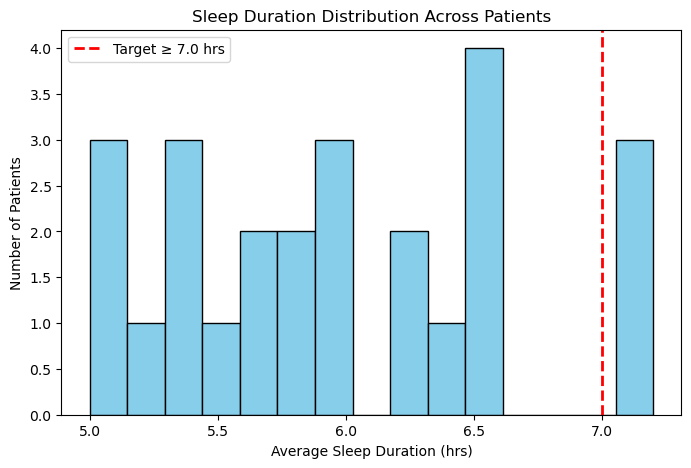

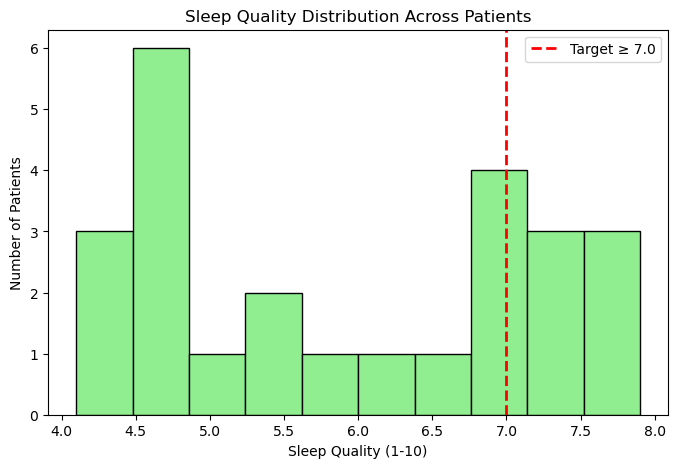

In [132]:
import matplotlib.pyplot as plt

# --- Sleep Duration Distribution ---
plt.figure(figsize=(8,5))
plt.hist(patients_sleep["Average Sleep Duration (hrs)"], bins=15, color="skyblue", edgecolor="black")
plt.axvline(SLEEP_HOURS_MIN, color="red", linestyle="dashed", linewidth=2, label=f"Target ≥ {SLEEP_HOURS_MIN} hrs")
plt.title("Sleep Duration Distribution Across Patients")
plt.xlabel("Average Sleep Duration (hrs)")
plt.ylabel("Number of Patients")
plt.legend()
plt.show()

# --- Sleep Quality Distribution ---
plt.figure(figsize=(8,5))
plt.hist(patients_sleep["Sleep Quality (1-10)"], bins=10, color="lightgreen", edgecolor="black")
plt.axvline(SLEEP_QUALITY_MIN, color="red", linestyle="dashed", linewidth=2, label=f"Target ≥ {SLEEP_QUALITY_MIN}")
plt.title("Sleep Quality Distribution Across Patients")
plt.xlabel("Sleep Quality (1-10)")
plt.ylabel("Number of Patients")
plt.legend()
plt.show()

# <span style="color:green">Sleep Analysis Insights</span>

## <span style="color:green">1. Sleep Duration Distribution Across Patients</span>
<span style="color:green">- A majority of patients are **not meeting the recommended 7+ hours of sleep**.</span>  
<span style="color:green">- There is **high variability** across patients (some near 5 hours, some closer to 7).</span>  
<span style="color:green">- This suggests that **sleep insufficiency is common**, and interventions may be needed to help patients reach the healthy threshold.</span>

## <span style="color:green">2. Sleep Quality Distribution Across Patients</span>
<span style="color:green">- A significant portion of patients experience **suboptimal sleep quality**.</span>  
<span style="color:green">- Even if some patients are close to 7 hours of sleep (duration), their **sleep quality is still below target**.</span>  
<span style="color:green">- This mismatch indicates that **sleep is not just about quantity, but also about restfulness**.</span>

## 9. What is the age and gender distribution of the patients in the study?

📊 Age Summary
count    25.000000
mean     46.680000
std      15.544881
min      20.000000
25%      34.000000
50%      46.000000
75%      62.000000
max      74.000000
Name: Age, dtype: float64

📊 Gender Distribution
Gender
Male      16
Female     9
Name: count, dtype: int64


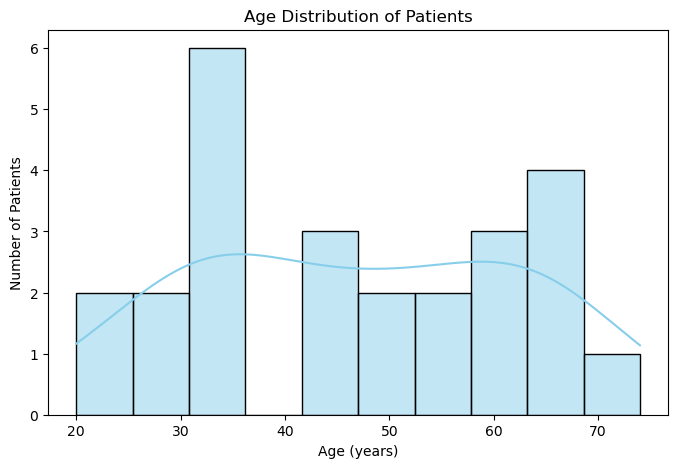

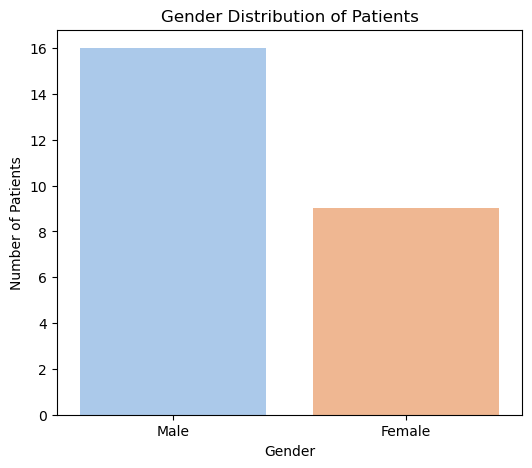

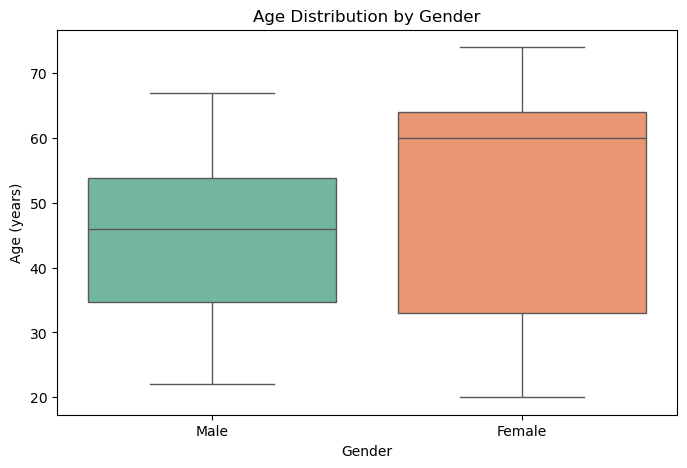

In [135]:
# --- Age & Gender Distribution ---

# Take unique patients only
patients_demo = dfT1DData.drop_duplicates(subset=["patient_id"])[["patient_id","Age","Gender"]]

# Summary stats for age
print("📊 Age Summary")
print(patients_demo["Age"].describe())

# Gender counts
print("\n📊 Gender Distribution")
print(patients_demo["Gender"].value_counts())

# --- Plot: Age Distribution ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(patients_demo["Age"], bins=10, kde=True, color="skyblue")
plt.title("Age Distribution of Patients")
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")
plt.show()

# --- Plot: Gender Distribution ---
plt.figure(figsize=(6,5))
sns.countplot(x="Gender", data=patients_demo, palette="pastel")
plt.title("Gender Distribution of Patients")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

# --- Plot: Age by Gender ---
plt.figure(figsize=(8,5))
sns.boxplot(x="Gender", y="Age", data=patients_demo, palette="Set2")
plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age (years)")
plt.show()

## <span style="color:green">INSIGHTS</span>

## <span style="color:green">1. Age Distribution of Patients</span>
<span style="color:green">- The study population covers a **broad age range**, but most patients cluster in **younger adulthood (30s)** and **older adulthood (60s)**.</span>  
<span style="color:green">- This suggests the dataset has **bimodal representation**, with younger and older patients more frequent, while mid-aged groups (40s–50s) are relatively fewer.</span>  
<span style="color:green">- Interventions may need to be **age-tailored**, as health concerns and sleep patterns differ significantly between younger and older adults.</span>

## <span style="color:green">2. Gender Distribution of Patients</span>
<span style="color:green">- The dataset is **male-dominant**, which may slightly bias findings if gender-related sleep or health differences are being studied.</span>  
<span style="color:green">- Further analysis should consider **gender as a factor** when interpreting sleep or health outcomes.</span>

## <span style="color:green">3. Age Distribution by Gender</span>
<span style="color:green">- **Females in the dataset are relatively older on average** than males.</span>  
<span style="color:green">- This difference in age distribution may influence **comparisons of sleep quality, glucose control, or lifestyle factors**, as age-related variations can affect outcomes.</span>  
<span style="color:green">- Age should be treated as a **confounding factor** in gender-based analyses.</span>

## 10. What percentage of patients report sleep disturbances, which may affect their glucose control and insulin sensitivity?

Average % with Sleep Disturbances across patients: 52.8%
Percentage of patients who report some disturbance: 100.0%


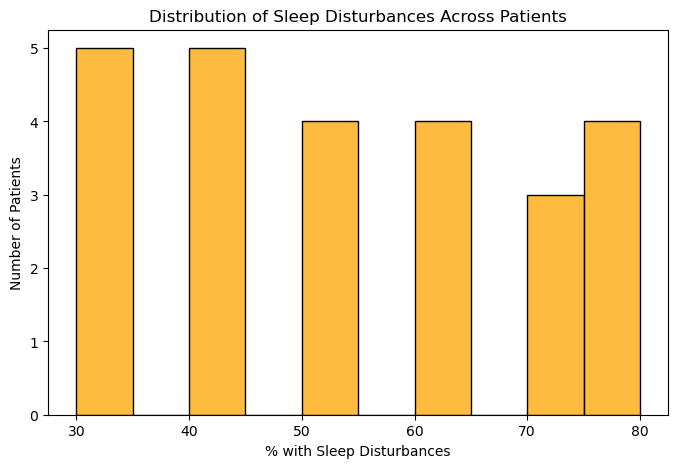

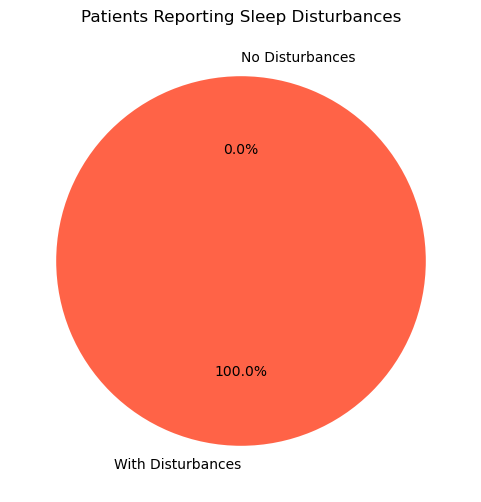

In [138]:
# --- Sleep Disturbances Analysis ---

# Take one record per patient
patients_sleep = dfT1DData.drop_duplicates(subset=["patient_id"])[
    ["patient_id", "% with Sleep Disturbances"]
]

#  Normalize to 0–100.
if patients_sleep["% with Sleep Disturbances"].max() <= 1:
    patients_sleep["% with Sleep Disturbances"] *= 100

# Overall average % of patients reporting disturbances
avg_disturbance_pct = patients_sleep["% with Sleep Disturbances"].mean()

# Count how many patients report ANY disturbance (>0%)
pct_any_disturbance = (patients_sleep["% with Sleep Disturbances"] > 0).mean() * 100

print(f"Average % with Sleep Disturbances across patients: {avg_disturbance_pct:.1f}%")
print(f"Percentage of patients who report some disturbance: {pct_any_disturbance:.1f}%")

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of disturbance %
plt.figure(figsize=(8,5))
sns.histplot(patients_sleep["% with Sleep Disturbances"], bins=10, color="orange", edgecolor="black")
plt.title("Distribution of Sleep Disturbances Across Patients")
plt.xlabel("% with Sleep Disturbances")
plt.ylabel("Number of Patients")
plt.show()

# Pie chart: any disturbance vs none
plt.figure(figsize=(6,6))
labels = ["With Disturbances", "No Disturbances"]
sizes = [pct_any_disturbance, 100 - pct_any_disturbance]
colors = ["tomato", "lightgreen"]
plt.pie(sizes, labels=labels, autopct="%.1f%%", colors=colors, startangle=90)
plt.title("Patients Reporting Sleep Disturbances")
plt.show()

# <span style="color:green">Sleep Disturbances Analysis</span>

## <span style="color:green">Observation</span>
<span style="color:green">- The **average percentage of sleep disturbances across patients** is **52.8%**.</span>  
<span style="color:green">- The distribution shows that patients experience disturbances anywhere between **30% and 80% of the time**.</span>  
<span style="color:green">- The pie chart indicates that **100% of patients report some level of sleep disturbance** (no patients reported zero disturbances).</span>

## <span style="color:green">Insight</span>
<span style="color:green">- Sleep disturbances are a **universal issue** in this patient population — every patient reports experiencing them.</span>  
<span style="color:green">- While all patients are affected, the **severity varies widely**, with some experiencing them nearly one-third of the time, while others face disturbances almost 80% of the time.</span>  
<span style="color:green">- The average being above **50%** highlights that **disturbed sleep is more frequent than restful sleep** for many patients.</span>  
<span style="color:green">- This suggests that addressing sleep disturbances should be a **key intervention priority**, potentially involving **sleep hygiene education, stress management, or medical evaluation**.</span>

## 11-What is the average basal insulin rate delivered by the pump over 24 hours for each patient?

In [7]:
import pandas as pd

# Step 1: group by patient and compute mean basal rate
avg_basal_rate =dfT1DData.groupby("patient_id")['basal_rate'].mean().reset_index()

# Step 2: rename column for clarity
avg_basal_rate.rename(columns={'basal_rate': 'avg_basal_rate_24h'}, inplace=True)

print(avg_basal_rate)

   patient_id  avg_basal_rate_24h
0   HUPA0001P            0.050352
1   HUPA0002P            0.089447
2   HUPA0003P            0.054557
3   HUPA0004P            0.073505
4   HUPA0005P            0.067564
5   HUPA0006P            0.076646
6   HUPA0007P            0.080174
7   HUPA0009P            0.091432
8   HUPA0010P            0.060669
9   HUPA0011P            0.000000
10  HUPA0014P            0.000000
11  HUPA0015P            0.000000
12  HUPA0016P            0.067004
13  HUPA0017P            0.060000
14  HUPA0018P            0.000000
15  HUPA0019P            0.064341
16  HUPA0020P            0.081384
17  HUPA0021P            0.019573
18  HUPA0022P            0.134350
19  HUPA0023P            0.036777
20  HUPA0024P            0.042140
21  HUPA0025P            0.093053
22  HUPA0026P            0.036980
23  HUPA0027P            0.040550
24  HUPA0028P            0.016012


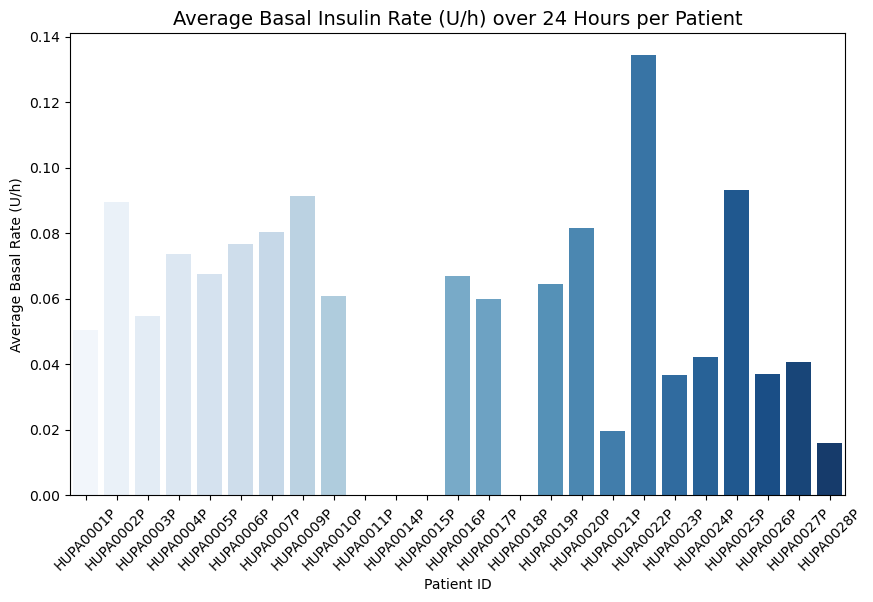

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))
sns.barplot(data=avg_basal_rate, x='patient_id', y='avg_basal_rate_24h', 
          palette="Blues",hue="patient_id")

plt.title("Average Basal Insulin Rate (U/h) over 24 Hours per Patient", fontsize=14)
plt.xlabel("Patient ID")
plt.ylabel("Average Basal Rate (U/h)")
plt.xticks(rotation=45)
plt.show()